# MNIST
## 12. Simple Neural Network

In [1]:
from infdsa_mnist import mnist_load_normalized, mnist_output, simple_nn, simple_nn_output
import numpy as np

For this section, we will implement a simple neural network to classify the MNIST dataset. It will use a simple Sequential model with a few dense layers. To ensure we can make accurate predictions, we will need to do the following:
- Normalize the pixel values of the images to be between 0 and 1.
- Flatten the 28x28 pixel images into a 1D array of 784 features.
- Train the neural network on the training data and evaluate its performance on the test set.

Since the nominal labels of the MNIST dataset are already in the form of integers (0-9), we can use them directly for training the neural network without needing to one-hot encode them, as the `sparse_categorical_crossentropy` loss function can handle integer labels directly. This simplifies our preprocessing steps and will use less memory to save the one-hot encoded labels.

In [2]:
(train_data, test_data) = mnist_load_normalized.load_mnist_flattened_normalized()
x_train, y_train = train_data
x_test, y_test = test_data

## Creating a Model

In [3]:
model = simple_nn.create_nn(x_train.shape[1])

The `create_nn` function initializes a simple neural network model. It takes the length of the input features (784 for the flattened MNIST images) as an argument and constructs a Sequential model with a few dense layers. The architecture of the model includes:
- An input layer that takes the argument as the number of input features.
- Two hidden layers with ReLU activation functions.
- An output layer with a softmax activation function.

The hidden layers are set up in the following way:
- They have 192 and 64 neurons respectively. These numbers are chosen to be a good balance between the specificity of the MNIST dataset, the embedded device constraints (as mentioned in earlier chapters), and the performance of this particular combination  compared to other combinations (256/128/64, 256/64, 128/64).
- They use the ReLU activation function, which helps the model learn non-linear relationships in the data.
- They use batch normalization to ensure the data is normalized at each layer every epoch. This helps with stability and training speed of the model.
- Dropout is being utilized to prevent overfitting by randomly dropping out a fraction of the neurons during training. This encourages the model to learn more robust features that are not reliant on any single neuron.

The output layer has 10 neurons (one for each digit class) and uses the softmax activation function to produce a probability distribution over the classes, allowing the model to make predictions based on the highest probability.

## Compiling the Model

In [4]:
simple_nn.compile_nn(model)

The `compile_nn` function compiles the neural network model by specifying the optimizer, loss function, and metrics to be used during training. For this simple neural network, we will use the following setup:
- Optimizer: Adam
- Loss function: Sparse Categorical Crossentropy (since our labels are integers)
- Metrics: Accuracy

## Fitting the Model

Epoch 25: early stopping
Restoring model weights from the end of the best epoch: 13.


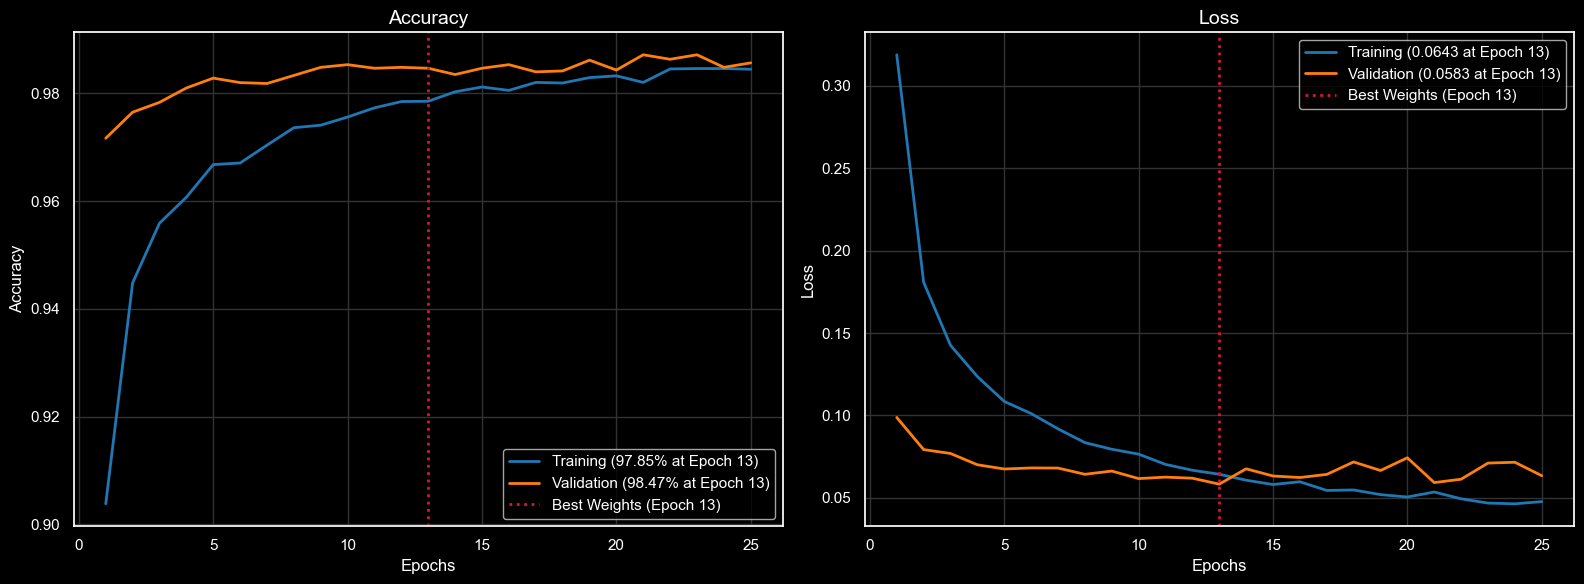

In [5]:
history = simple_nn.fit_nn(model, x_train, y_train, epochs=100, batch_size=16)

simple_nn_output.plot_nn_history(history)

 Test accuracy: 98.49%, Test loss: 0.0537


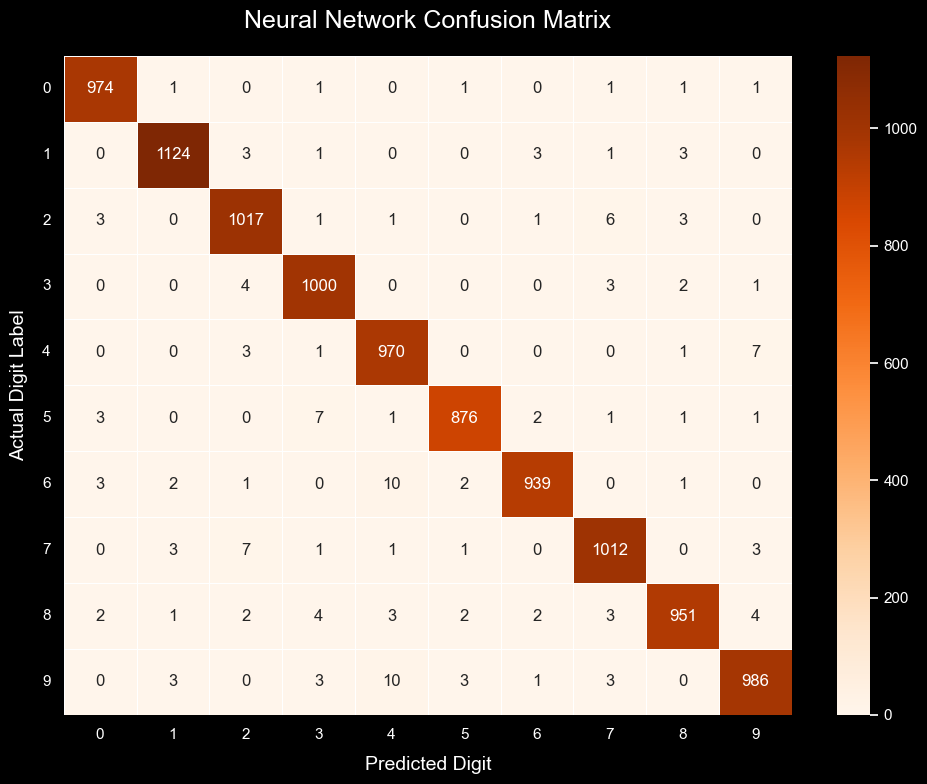

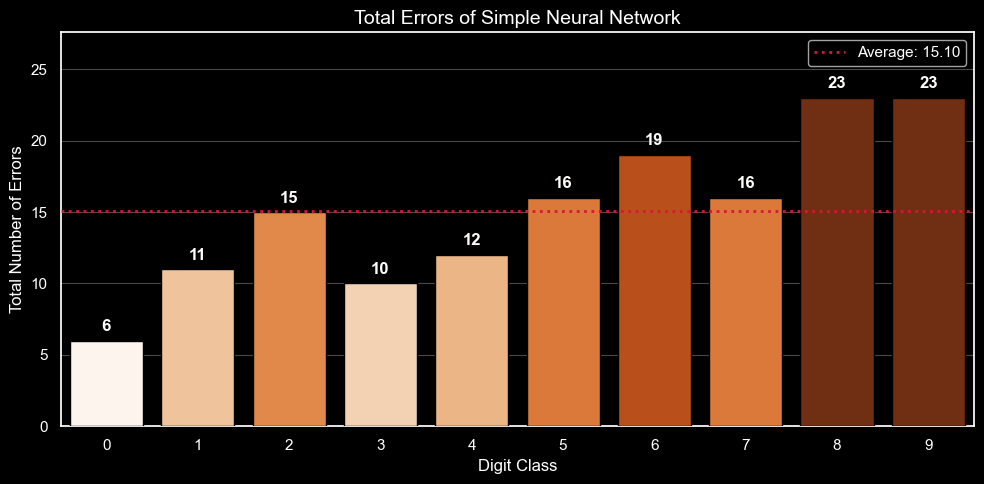

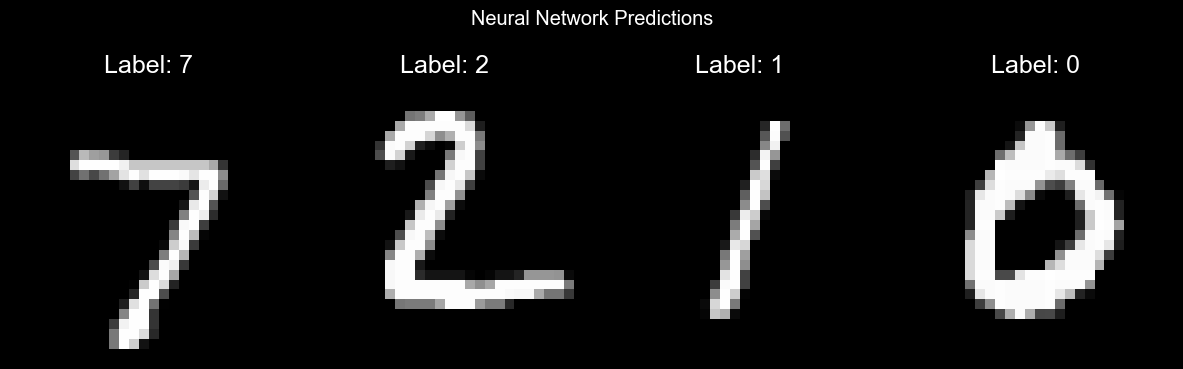

In [6]:
loss, acc = simple_nn.evaluate_nn(model, x_test, y_test)
print(f" Test accuracy: {acc * 100:.2f}%, Test loss: {loss:.4f}")

predictions = model.predict(x_test, verbose=0)
predicted_digits = np.argmax(predictions, axis=1)

cm = mnist_output.create_confusion_matrix(y_test, predicted_digits)
simple_nn_output.display_full_confusion_matrix(cm, title="Neural Network Confusion Matrix")

mnist_output.display_total_errors_barplot(cm, title="Total Errors of Simple Neural Network")

unseen_digits_imgs = x_test[0:4].reshape(-1, 28, 28)
mnist_output.display_images(x=unseen_digits_imgs, y=predicted_digits[0:4], title="Neural Network Predictions")


## Evaluating the Model

The model achieves around 98.4% accuracy on the test set. This is a sizable jump from our previous mode, the K-Means algorithm, which had 95.27% accuracy. The improvement is in no small part due to the fact the neural network can learn complex patterns in the data, whereas K-Means is a much simpler algorithm that relies on distance-based clustering.

More important than the accuracy is the ability to be deployed on the embedded device we have mentioned in previous chapter. As a reminder, the embedded device has the following constraints:
- 256 KB of RAM
- 1 MB of storage
- No GPU



In [7]:
filename = "mnist_model_full.keras"

model, filepath_full = simple_nn.save_nn(model, filename)

In [8]:
simple_nn_output.nn_summary(model, filepath_full)

Model: ../models/mnist_model_full.keras
Size (KB): 2610.57 KB
Size (MB): 2.55 MB


This model is around 2.55 MB in size, which is more than double the 1 MB storage constraint of our embedded device. This means we will need to optimize the model further to reduce its size before it can be deployed on the device.

Considering what we aim to do at this stage, the optimizer is no longer needed, so we can remove it from the model to reduce the size.

In [9]:
filename = "mnist_model_optimized.keras"

optimized_model, filepath_optimized = simple_nn.save_nn(model, filename, include_optimizer=False)

In [10]:
simple_nn_output.nn_summary(optimized_model, filepath_optimized)

Model: ../models/mnist_model_optimized.keras
Size (KB): 891.65 KB
Size (MB): 0.87 MB


Removing the optimizer from the model reduces its size from 2.55 MB to 891.65 KB, which is within the 1 MB storage constraint of the embedded device. However, loading this into RAM is impossible at its current size, so we need to further optimize the model to reduce its size and memory footprint. We can achieve this by quantizing the model. This means we convert the parameters of the model from `float32` to `uint8`. This will reduce the size of the model by a factor of 4x and make it more suitable for deployment on the embedded device. For this task, we will use TensorFlow Lite.

In [11]:
filename = "mnist_model_quantized.tflite"

filepath_quantized = simple_nn.quantize_nn(x_train, optimized_model, filename)

INFO:tensorflow:Assets written to: /var/folders/6y/f0bhrqh16zs4rk11plkrbdqr0000gn/T/tmp96q4y_z5/assets


INFO:tensorflow:Assets written to: /var/folders/6y/f0bhrqh16zs4rk11plkrbdqr0000gn/T/tmp96q4y_z5/assets


Saved artifact at '/var/folders/6y/f0bhrqh16zs4rk11plkrbdqr0000gn/T/tmp96q4y_z5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 784), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  4860081168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4860078864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4860081552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4860079056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4860083088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4860079440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4860076560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4860074448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4860074832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4860075024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4860076752: TensorSpec(shape

/Users/faye/Documents/GitHub/INFDSA_MNIST/.venv/lib/python3.13/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1778165408.316942 34070073 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1778165408.316951 34070073 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1778165408.317128 34070073 reader.cc:83] Reading SavedModel from: /var/folders/6y/f0bhrqh16zs4rk11plkrbdqr0000gn/T/tmp96q4y_z5
I0000 00:00:1778165408.317420 34070073 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1778165408.317423 34070073 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/6y/f0bhrqh16zs4rk11plkrbdqr0000gn/T/tmp96q4y_z5
I0000 00:00:1778165408.319657 34070073 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1778165408.320129 34070073 loader.cc:236] R

In [12]:
simple_nn_output.nn_summary(filepath_quantized, filename)

File: ../models/mnist_model_quantized.tflite
Size (KB): 224.77 KB
Size (MB): 0.22 MB


Quantizing the model reduces its size from 891.65 KB to 224.77 KB, which is a significant reduction and allows it to be fully loaded into RAM on the embedded device. However, quantization could lead to a drop in accuracy. To evaluate this, we can use TensorFlow Lite's interpreter to run inference on the test set and compare the predictions to the actual labels. This will give us an idea of how well the quantized model performs compared to the original model.

In [13]:
quantized_acc = simple_nn.evaluate_quantized_nn(filepath_quantized, x_test, y_test)

Evaluating TFLite model on 10000 samples...
Test samples: 10000
Correct predictions: 9847
Test accuracy: 98.47%


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Model Stage,Storage Size (KB),Test Accuracy
Full Model,2610.57 KB,98.49%
Optimized (No Optimizer),891.65 KB,98.49%
Quantized (uint8),224.77 KB,98.47%


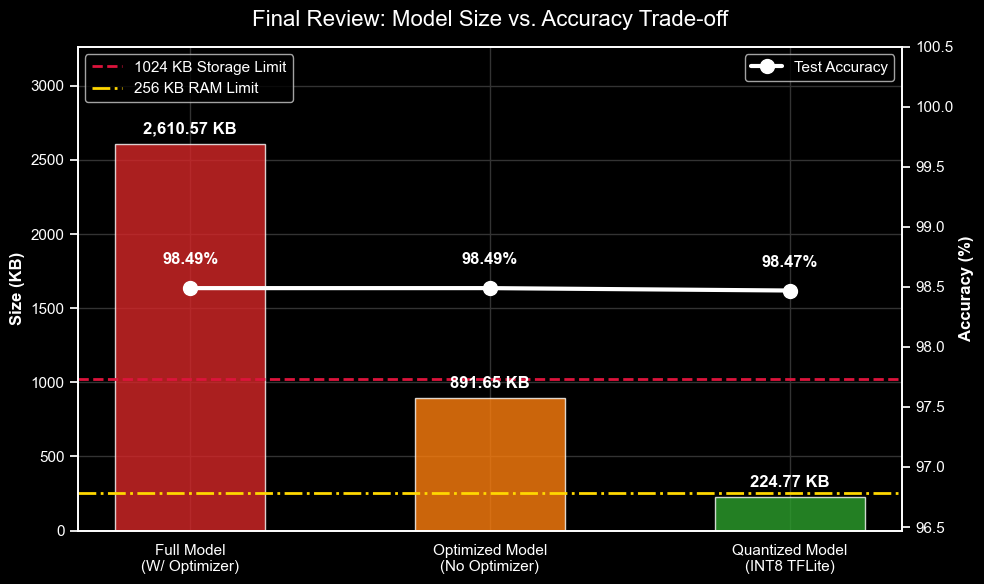

In [14]:
summary_data = simple_nn.create_summary_data(filepath_full, filepath_optimized, filepath_quantized, acc, quantized_acc)

table = mnist_output.create_dataset_table(
    columns=["Model Stage", "Storage Size (KB)", "Test Accuracy"],
    data=summary_data,
    caption="Neural Network Optimization Summary"
)
display(table)

simple_nn_output.plot_model_comparison(
    full_acc=acc,
    quant_acc=quantized_acc,
    full_path=filepath_full,
    opt_path=filepath_optimized,
    quant_path=filepath_quantized
)

The exact accuracy of the models can vary a bit per run since the training process is not deterministic, but it is consistently between 98.2% to 98.5% for any of the models. This means the quantization process has no significant impact on the accuracy of the model, which makes it a very effective optimization technique for our use case. 224.77 KB is small enough to be deployed on the embedded device and loaded into RAM without any issues, while maintaining a high level of accuracy. This demonstrates the power of quantization in optimizing neural networks for deployment on resource-constrained devices.